## Simulating CAR T-Cell Therapy with Patient Preconditioning

This notebook simulates the effect of CAR T-Cell therapy
preconditioned by sequential administration of chemotherapy
based on the ODEs in [this paper](https://link.springer.com/article/10.1007/s11538-021-00869-5).

In [217]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

### Model parameters

These are the parameters listed in Table 1, with parameters listed
in the same order as they appear in the table. They are listed
exactly as they appear with the only exception being $b$, which is given
as $1/b$ but listed as $b$ here.

In [218]:
# parameters are listedin the following order:
# a, b, dE, dC, g, jE, jC, K, k, l, mE, mC, qE, qC, s, KT, KE, KC, gamma

PARAMS_PAT_1234 = [
    [2.55e-1,     1.76e-1,    5.14e-1,       5.14e-1],
    [5e-13,       5e-13,      1 / 9.804e8,   1 / 9.804e8],
    [2.03,        2.03,       5.80,          4.23],
    [2.25,        2.25,       2.25,          2.25],
    [1.4e3,       4.7e4,      1.3e4,         1.3e4],
    [1.1e-2,      7.46e-3,    2.7e-2,        2.7e-2],
    [2.42e-1,     1.65e-1,    6.0e-1,        6.0e-1],
    [1.65e9,      1.65e9,     1.65e8,        1.65e8],
    [2.019e5,     7.0e7,      2.0e7,         2.0e7],
    [1.395,       1.419,      1.43,          1.43],
    [7e-3,        3.4e-2,     2e-2,          2e-2],
    [2.93e-2,     2.93e-2,    2.93e-2,       2.93e-2],
    [3.42e-11,    6.716e-11,  3.42e-10,      3.42e-10],
    [3.0e-11,     3.0e-11,    1.53e-9,       1.53e-9],
    [3.05e-1,     3.05e-1,    2.5e-1,        3.6e-1],
    [7e-1,        7e-1,       7e-1,          7e-1],
    [6e-1,        6e-1,       6e-1,          6e-1],
    [6e-1,        6e-1,       6e-1,          6e-1],
    [9e-1,        9e-1,       9e-1,          9e-1],
]

PARAMS_PAT_1 = [x[0] for x in PARAMS_PAT_1234]
PARAMS_PAT_2 = [x[1] for x in PARAMS_PAT_1234]
PARAMS_PAT_3 = [x[2] for x in PARAMS_PAT_1234]
PARAMS_PAT_4 = [x[3] for x in PARAMS_PAT_1234]

### Defining and simulating the model

Here, we simulate the differential equations using `scipy.integrate.odeint`.
In the paper, the injections of chemotherapy and CAR T-Cells are modeled
as time-dependent forcing terms $v_M(t)$ and $v_C(t)$; to simplify things here,
we model the injections as being instantaneous.

In [219]:
def model(y, t, params):
    """
    This takes in the vector [T, E, C, M] as `y` and returns
    the vector of their time-derivatives given the model `params`.
    The `params` should be listed in the same order as in the paper,
    and and `params[1]` should be b instead of 1/b.
    """
    T, E, C, M = y
    a, b, dE, dC, g, jE, jC, K, k, l, mE, mC, qE, qC, s, KT, KE, KC, gamma = params
    if t == 0:
        print(mC)

    # epsilon = 1e-10
    # C = max(C, epsilon)
    # E = max(E, epsilon)
    # T = max(T, epsilon)
    
    import warnings
    def sw(m, c, fn, ln, f, l):
        print(m)
        print(t, T, E, C, M)
    warnings.showwarning = sw

    # try to avoid division by 0
    tol = 1e-10
    if T < tol:
        DE = 0
    elif E < T:
        DE = dE * (E / T)**l / (s + (E / T)**l) * T
    else:
        DE = dE * (1 - s / (s + (T/E)**(-l))) * T

    if T < tol:
        DC = 0
    elif C < T:
        DC = dC * (C / T)**l / (s + (C / T)**l) * T
    else:
        DC = dC * (1 - s / (s + (T/C)**(-l))) * T
    
    dT_dt = a * T * (1 - b * T) - DE - DC - KT * (1 - np.exp(-M)) * T
    dE_dt = g - mE * E - jE * np.log((E + C) / K) * (DE**2) / (k + DE**2) * E  - qE * E * T - KE * (1 - np.exp(-M)) * E
    dC_dt = - mC * C - jC * np.log((E + C) / K) * (DC**2) / (k + DC**2) * C - qC * C * T - KC * (1 - np.exp(-M)) * C
    dM_dt = - gamma * M

    # if 6 <= t <= 20:
    #     print(t, C, np.array([
    #         mC * C, 
    #         np.log((E + C) / K),
    #         (DC**2) / (k + DC**2),
    #         jC * np.log((E + C) / K) * (DC**2) / (k + DC**2) * C,
    #         qC * C * T,
    #         KC * (1 - np.exp(-M)) * C,
    #     ]))

    return [dT_dt, dE_dt, dC_dt, dM_dt]

def simulate(model, y0, params, injection_times_M, dosage_M, injection_time_C, dosage_C, t_initial, t_final, time_step):
    """
    Simulates CAR T-cell therapy with preconditioning, returning a
    tuple containing an NDArray of times and corresponding NDArray of y-values.

    Both chemotherapy and CAR T-cell injections are modeled as being instantaneous.
    """
    t_vals = np.array([t_initial])
    y_vals = np.array([y0])
    
    def simulate_between(y_start, t_start, t_end):
        """
        Computes (t, y0) where t = [t_start + time_step, t_start + 2*time_step, ..., t_end] 
        and y is the corresponding list of y-values, and appends them
        to t_vals and y_vals. t_start and y_start are not appended since
        they are already included in t_vals and y_vals.
        """
        nonlocal t_vals, y_vals
        t_between = np.arange(t_start, t_end + time_step, time_step)
        y_between = odeint(model, y_start, t_between, args=(params,))
        t_vals = np.concatenate((t_vals, t_between[1:]))
        y_vals = np.vstack((y_vals, y_between[1:]))
    
    simulate_between(y0, t_initial, injection_times_M[0])

    # chemo injections, modeled as instantaneous increases in chemo concentration
    y_vals[-1] += [0, 0, 0, dosage_M]
    for i in range(1, len(injection_times_M)):
        simulate_between(y_vals[-1], injection_times_M[i-1], injection_times_M[i])
        y_vals[-1] += [0, 0, 0, dosage_M]

    simulate_between(y_vals[-1], injection_times_M[-1], injection_time_C)
    # car t-cell injection, modeled as an instantaneous increase in car t-cell count
    # page 11: the effective dose is modeled as 1% of the injected dose level
    y_vals[-1] += [0, 0, 0.01 * dosage_C, 0]

    # finish the simulation
    simulate_between(y_vals[-1], injection_time_C, t_final)

    return t_vals, y_vals

In [248]:
# fix this later
def plot_graphs(t, y, xmax=50):
    fig, axs = plt.subplots(2)
    # plt.figure(figsize=(14, 8))
    T, E, C, M = y[:, 0], y[:, 1], y[:, 2], y[:, 3]
    axs[1].plot(t, T, label="Tumor Cells T(t)", color="red", linewidth=2)
    axs[1].plot(t, E, label="Effector Cells E(t)", color="blue", linewidth=2)
    axs[1].plot(t, C, label="CAR-T Cells C(t)", color="orange", linewidth=2)
    axs[0].plot(t, M, label="Chemo conc.", color="green", linewidth=2)
    # plt.yscale('log')
    axs[1].set_yscale('log')
    axs[1].yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=5))
    axs[1].grid(True, which="major", axis="y", linewidth=1)
    axs[1].grid(True, which="major", axis="x", linewidth=1)

    axs[0].set_xlim(0, 10)
    axs[0].set_ylim(0, 10)
    axs[1].set_xlim(0, xmax)
    axs[1].set_ylim(1, 1e15)

    axs[0].set_xlabel('Time (days)')
    axs[0].set_ylabel('Conc.')
    axs[1].set_xlabel('Time (days)')
    axs[1].set_ylabel('Cells')
    # plt.title('Cancer Cell Population Dynamics with Treatment')
    axs[0].legend(loc='best')
    axs[1].legend(loc='best')
    plt.show()

In [249]:
y0_pat_1 = [5e9, 4e5, 0, 0]
y0_pat_2 = [5e9, 4e5, 0, 0]
y0_pat_3 = [5e8, 4e5, 0, 0]
y0_pat_4 = [5e8, 4e5, 0, 0]

# 3-day high-strength + 4 days of rest
injection_times_M_1, dosage_M_1= [0, 1, 2], 5
injection_time_C_1, dosage_C_1 = 6, 2.5e8
# 5-day medium-strength + 2 days of rest
injection_times_M_2, dosage_M_2 = [0, 1, 2, 3, 4], 2.5
injection_time_C_2, dosage_C_2 = 6, 1e7

0.0293


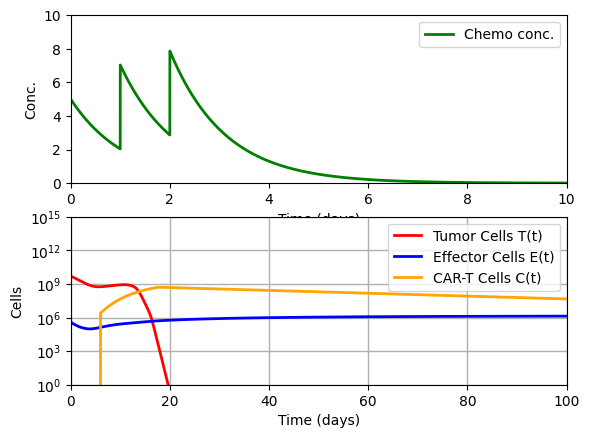

In [250]:
t, y = simulate(
    model,
    y0_pat_2,
    PARAMS_PAT_2,
    injection_times_M=injection_times_M_1,
    injection_time_C=injection_time_C_1,
    dosage_M=dosage_M_1,
    dosage_C=dosage_C_1,
    t_initial=0,
    t_final=100,
    time_step=0.001
)
# print(y[:50])




plot_graphs(t, y, xmax=100)